# Baseline IDS Analysis — CICIDS2023


This notebook covers:
- Dataset exploration and class distribution
- Data preprocessing (encoding, NaN handling, infinite value removal)
- Binary classification: Normal vs Attack
- Multi-class classification across all attack types
- Feature importance analysis
- Baseline results for comparison against adaptive model

## 1. Imports

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay, f1_score,
    balanced_accuracy_score
)

plt.rcParams['figure.dpi'] = 120
print('Imports OK')

Imports OK


## 2. Load Dataset

In [15]:

df = pd.read_csv('../datasets/cicids2023/Merged01.csv')

print(f'File loaded  : Merged01.csv')
print(f'Total rows   : {len(df):,}')
print('Missing values:', df.isnull().sum().sum())


File loaded  : Merged01.csv
Total rows   : 712,311
Missing values: 22


## 3. Exploratory Data Analysis

Class distribution:
Label
DDOS-ICMP_FLOOD            108662
DDOS-UDP_FLOOD              82011
DDOS-TCP_FLOOD              68289
DDOS-PSHACK_FLOOD           62171
DDOS-RSTFINFLOOD            61652
DDOS-SYN_FLOOD              61460
DDOS-SYNONYMOUSIP_FLOOD     54749
DOS-UDP_FLOOD               50371
DOS-TCP_FLOOD               40391
DOS-SYN_FLOOD               30620
BENIGN                      16577
MIRAI-GREETH_FLOOD          15135
MIRAI-UDPPLAIN              13342
MIRAI-GREIP_FLOOD           11187
DDOS-ICMP_FRAGMENTATION      6784
VULNERABILITYSCAN            5805
MITM-ARPSPOOFING             4590
DDOS-ACK_FRAGMENTATION       4308
DDOS-UDP_FRAGMENTATION       4264
DNS_SPOOFING                 2738
RECON-HOSTDISCOVERY          2045
RECON-OSSCAN                 1433
RECON-PORTSCAN               1251
DOS-HTTP_FLOOD               1113
DDOS-HTTP_FLOOD               416
DDOS-SLOWLORIS                354
DICTIONARYBRUTEFORCE          204
BROWSERHIJACKING               83
SQLINJECTION          

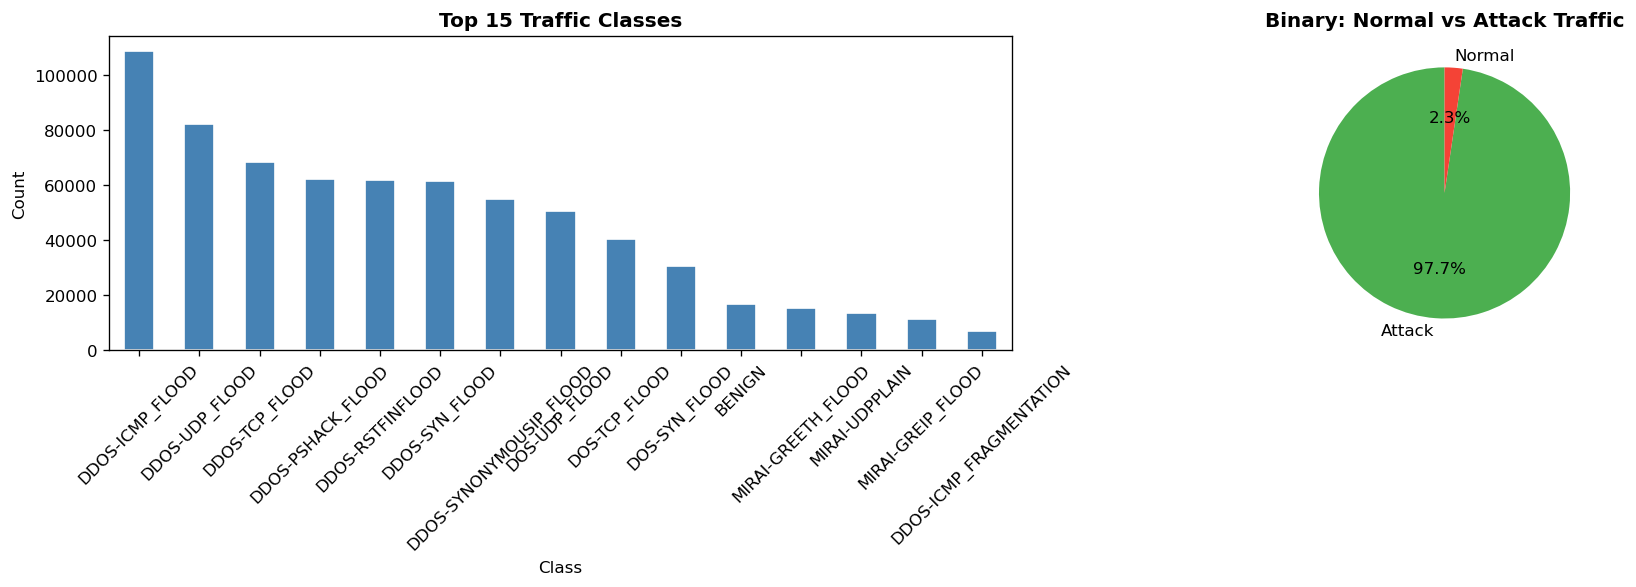

In [3]:
label_counts = df['Label'].value_counts()
print('Class distribution:')
print(label_counts.to_string())
print(f'\nTotal classes: {len(label_counts)}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

label_counts.head(15).plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Top 15 Traffic Classes', fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

df['Binary_Label'] = df['Label'].apply(lambda x: 'Normal' if x == 'BENIGN' else 'Attack')
binary_counts = df['Binary_Label'].value_counts()
axes[1].pie(binary_counts, labels=binary_counts.index, autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'], startangle=90)
axes[1].set_title('Binary: Normal vs Attack Traffic', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/class_distribution.png', bbox_inches='tight')
plt.show()

## 4. Data Preprocessing

In [4]:
df_clean = df.copy()

# Remove NaN and infinite values
df_clean = df_clean.dropna()
df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)
df_clean = df_clean.dropna()
print(f'After NaN removal: {df_clean.shape}')

# Drop classes with fewer than 2 samples (minimum needed for stratified split)
class_counts = df_clean['Label'].value_counts()
valid_classes = class_counts[class_counts >= 2].index
removed = class_counts[class_counts < 2].index.tolist()
if removed:
    print(f'Removing {len(removed)} class(es) with < 2 samples: {removed}')
else:
    print('No classes removed — all classes have sufficient samples')
df_clean = df_clean[df_clean['Label'].isin(valid_classes)].copy()
print(f'Clean dataset shape: {df_clean.shape}')

# Show rare class counts to confirm SQL Injection and UPLOADING_ATTACK are present
print('\nRare class sample counts:')
for cls in ['SQLINJECTION', 'UPLOADING_ATTACK', 'XSS', 'COMMANDINJECTION', 'BACKDOOR_MALWARE']:
    print(f'  {cls}: {class_counts.get(cls, 0)}')

# Multi-class label encoding
encoder = LabelEncoder()
df_clean['Label_encoded'] = encoder.fit_transform(df_clean['Label'])
print(f'\nClasses ({len(encoder.classes_)}): {list(encoder.classes_)}')

# Binary label encoding
df_clean['Binary_encoded'] = (df_clean['Binary_Label'] == 'Attack').astype(int)

# Feature matrix
feature_cols = [c for c in df_clean.columns
                if c not in ['Label', 'Binary_Label', 'Label_encoded', 'Binary_encoded']]
X = df_clean[feature_cols]
print(f'Features: {len(feature_cols)}')

After NaN removal: (712297, 41)
No classes removed — all classes have sufficient samples
Clean dataset shape: (712297, 41)

Rare class sample counts:
  SQLINJECTION: 77
  UPLOADING_ATTACK: 20
  XSS: 67
  COMMANDINJECTION: 73
  BACKDOOR_MALWARE: 41

Classes (34): ['BACKDOOR_MALWARE', 'BENIGN', 'BROWSERHIJACKING', 'COMMANDINJECTION', 'DDOS-ACK_FRAGMENTATION', 'DDOS-HTTP_FLOOD', 'DDOS-ICMP_FLOOD', 'DDOS-ICMP_FRAGMENTATION', 'DDOS-PSHACK_FLOOD', 'DDOS-RSTFINFLOOD', 'DDOS-SLOWLORIS', 'DDOS-SYNONYMOUSIP_FLOOD', 'DDOS-SYN_FLOOD', 'DDOS-TCP_FLOOD', 'DDOS-UDP_FLOOD', 'DDOS-UDP_FRAGMENTATION', 'DICTIONARYBRUTEFORCE', 'DNS_SPOOFING', 'DOS-HTTP_FLOOD', 'DOS-SYN_FLOOD', 'DOS-TCP_FLOOD', 'DOS-UDP_FLOOD', 'MIRAI-GREETH_FLOOD', 'MIRAI-GREIP_FLOOD', 'MIRAI-UDPPLAIN', 'MITM-ARPSPOOFING', 'RECON-HOSTDISCOVERY', 'RECON-OSSCAN', 'RECON-PINGSWEEP', 'RECON-PORTSCAN', 'SQLINJECTION', 'UPLOADING_ATTACK', 'VULNERABILITYSCAN', 'XSS']
Features: 39


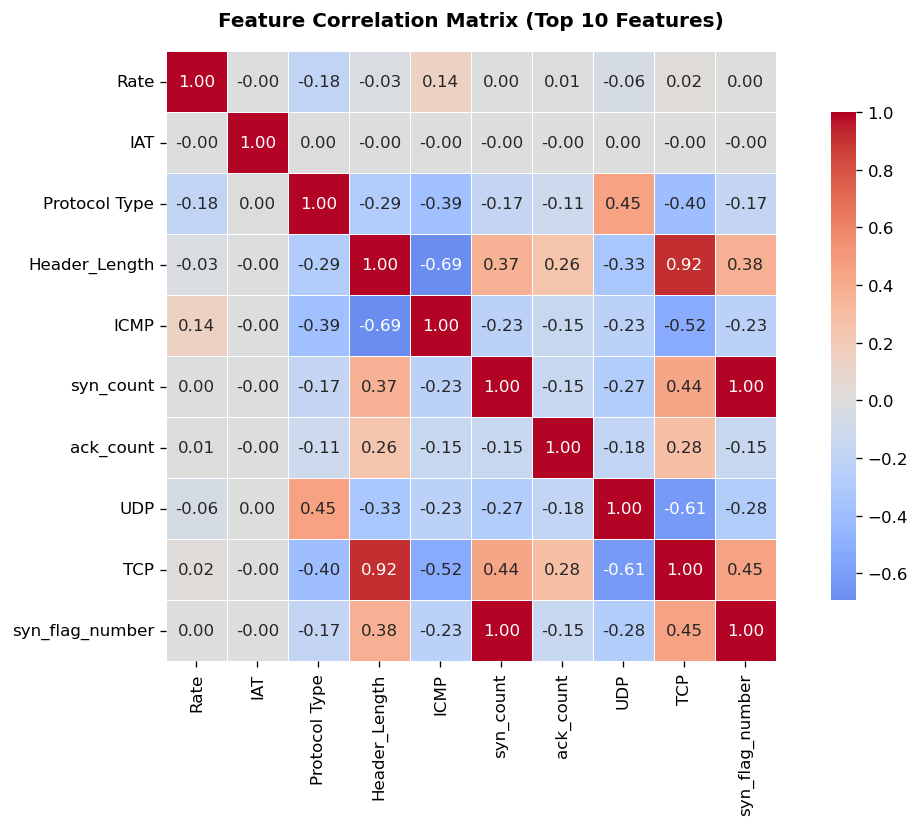

In [5]:
# Feature correlation heatmap
top_features = ['Rate', 'IAT', 'Protocol Type', 'Header_Length', 'ICMP',
                'syn_count', 'ack_count', 'UDP', 'TCP', 'syn_flag_number']

plt.figure(figsize=(10, 7))
corr = df_clean[top_features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix (Top 10 Features)', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../results/feature_correlation.png', bbox_inches='tight')
plt.show()

## 5. Binary Classification — Normal vs Attack

In [6]:
y_binary = df_clean['Binary_encoded']
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)
print(f'Train: {len(X_train_b)}  |  Test: {len(X_test_b)}')

rf_binary = RandomForestClassifier(n_estimators=100, random_state=42,
                                    n_jobs=-1, class_weight='balanced')
rf_binary.fit(X_train_b, y_train_b)

y_pred_b = rf_binary.predict(X_test_b)
acc_b     = accuracy_score(y_test_b, y_pred_b)
f1_b      = f1_score(y_test_b, y_pred_b, average='weighted')
bal_acc_b = balanced_accuracy_score(y_test_b, y_pred_b)

print(f'\nBinary Classification Results')
print(f'Accuracy          : {acc_b:.4f} ({acc_b*100:.2f}%)')
print(f'Balanced Accuracy : {bal_acc_b:.4f} ({bal_acc_b*100:.2f}%)')
print(f'F1 Score (weighted): {f1_b:.4f}')
print()
print(classification_report(y_test_b, y_pred_b,
                             target_names=['Normal', 'Attack'], zero_division=0))

Train: 569837  |  Test: 142460

Binary Classification Results
Accuracy          : 0.9920 (99.20%)
Balanced Accuracy : 0.9102 (91.02%)
F1 Score (weighted): 0.9920

              precision    recall  f1-score   support

      Normal       0.83      0.82      0.83      3315
      Attack       1.00      1.00      1.00    139145

    accuracy                           0.99    142460
   macro avg       0.91      0.91      0.91    142460
weighted avg       0.99      0.99      0.99    142460




Binary Classification Results
Accuracy          : 0.9920 (99.20%)
Balanced Accuracy : 0.9110 (91.10%)
F1 Score (weighted): 0.9920

              precision    recall  f1-score   support

      Normal       0.83      0.83      0.83      3315
      Attack       1.00      1.00      1.00    139145

    accuracy                           0.99    142460
   macro avg       0.91      0.91      0.91    142460
weighted avg       0.99      0.99      0.99    142460



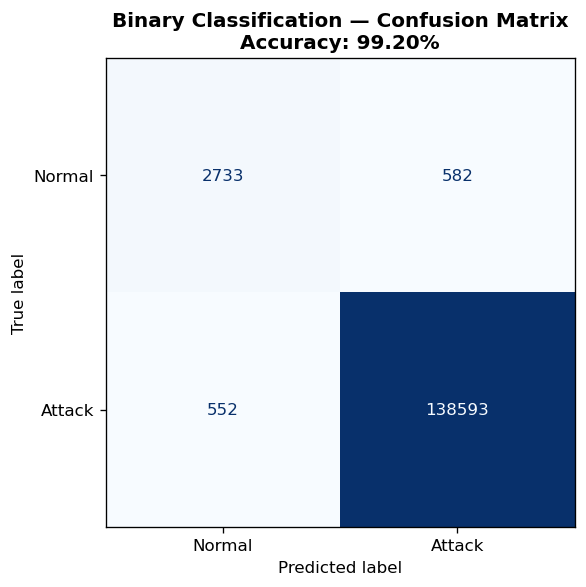

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
cm_b = confusion_matrix(y_test_b, y_pred_b)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_b, display_labels=['Normal', 'Attack'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Binary Classification — Confusion Matrix\nAccuracy: {acc_b*100:.2f}%',
             fontweight='bold')
plt.tight_layout()
plt.savefig('../results/binary_confusion_matrix.png', bbox_inches='tight')
plt.show()

### False Positive Rate (Binary)

In [8]:
tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
fpr_b = fp_b / (fp_b + tn_b)
print(f'Binary Confusion Matrix: TN={tn_b}, FP={fp_b}, FN={fn_b}, TP={tp_b}')
print(f'Binary False Positive Rate (FPR): {fpr_b:.4f} ({fpr_b*100:.2f}%)')

Binary Confusion Matrix: TN=2733, FP=582, FN=552, TP=138593
Binary False Positive Rate (FPR): 0.1756 (17.56%)


## 6. Multi-Class Classification — All Attack Types

In [9]:
y_multi = df_clean['Label_encoded']
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)

rf_multi = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42,
                                   n_jobs=2, class_weight='balanced')
rf_multi.fit(X_train_m, y_train_m)

y_pred_m  = rf_multi.predict(X_test_m)
acc_m     = accuracy_score(y_test_m, y_pred_m)
f1_macro  = f1_score(y_test_m, y_pred_m, average='macro',    zero_division=0)
f1_w      = f1_score(y_test_m, y_pred_m, average='weighted', zero_division=0)
bal_acc_m = balanced_accuracy_score(y_test_m, y_pred_m)

print('Multi-Class Results (with class_weight=balanced, max_depth=20)')
print(f'Accuracy          : {acc_m:.4f} ({acc_m*100:.2f}%)')
print(f'Balanced Accuracy : {bal_acc_m:.4f} ({bal_acc_m*100:.2f}%)')
print(f'Macro F1 Score    : {f1_macro:.4f}   <-- headline metric')
print(f'Weighted F1 Score : {f1_w:.4f}')
print()
print(classification_report(y_test_m, y_pred_m,
                             target_names=encoder.classes_, zero_division=0))


Multi-Class Results (with class_weight=balanced, max_depth=20)
Accuracy          : 0.7607 (76.07%)
Balanced Accuracy : 0.5900 (59.00%)
Macro F1 Score    : 0.5844   <-- headline metric
Weighted F1 Score : 0.7562

                         precision    recall  f1-score   support

       BACKDOOR_MALWARE       0.00      0.00      0.00         8
                 BENIGN       0.82      0.80      0.81      3315
       BROWSERHIJACKING       0.25      0.06      0.10        17
       COMMANDINJECTION       0.86      0.40      0.55        15
 DDOS-ACK_FRAGMENTATION       0.99      0.99      0.99       861
        DDOS-HTTP_FLOOD       0.81      0.72      0.76        83
        DDOS-ICMP_FLOOD       1.00      1.00      1.00     21732
DDOS-ICMP_FRAGMENTATION       0.98      0.99      0.98      1357
      DDOS-PSHACK_FLOOD       1.00      1.00      1.00     12434
       DDOS-RSTFINFLOOD       1.00      1.00      1.00     12330
         DDOS-SLOWLORIS       0.44      0.87      0.58        71
DDOS-SY

### Multi-Class Confusion Matrix

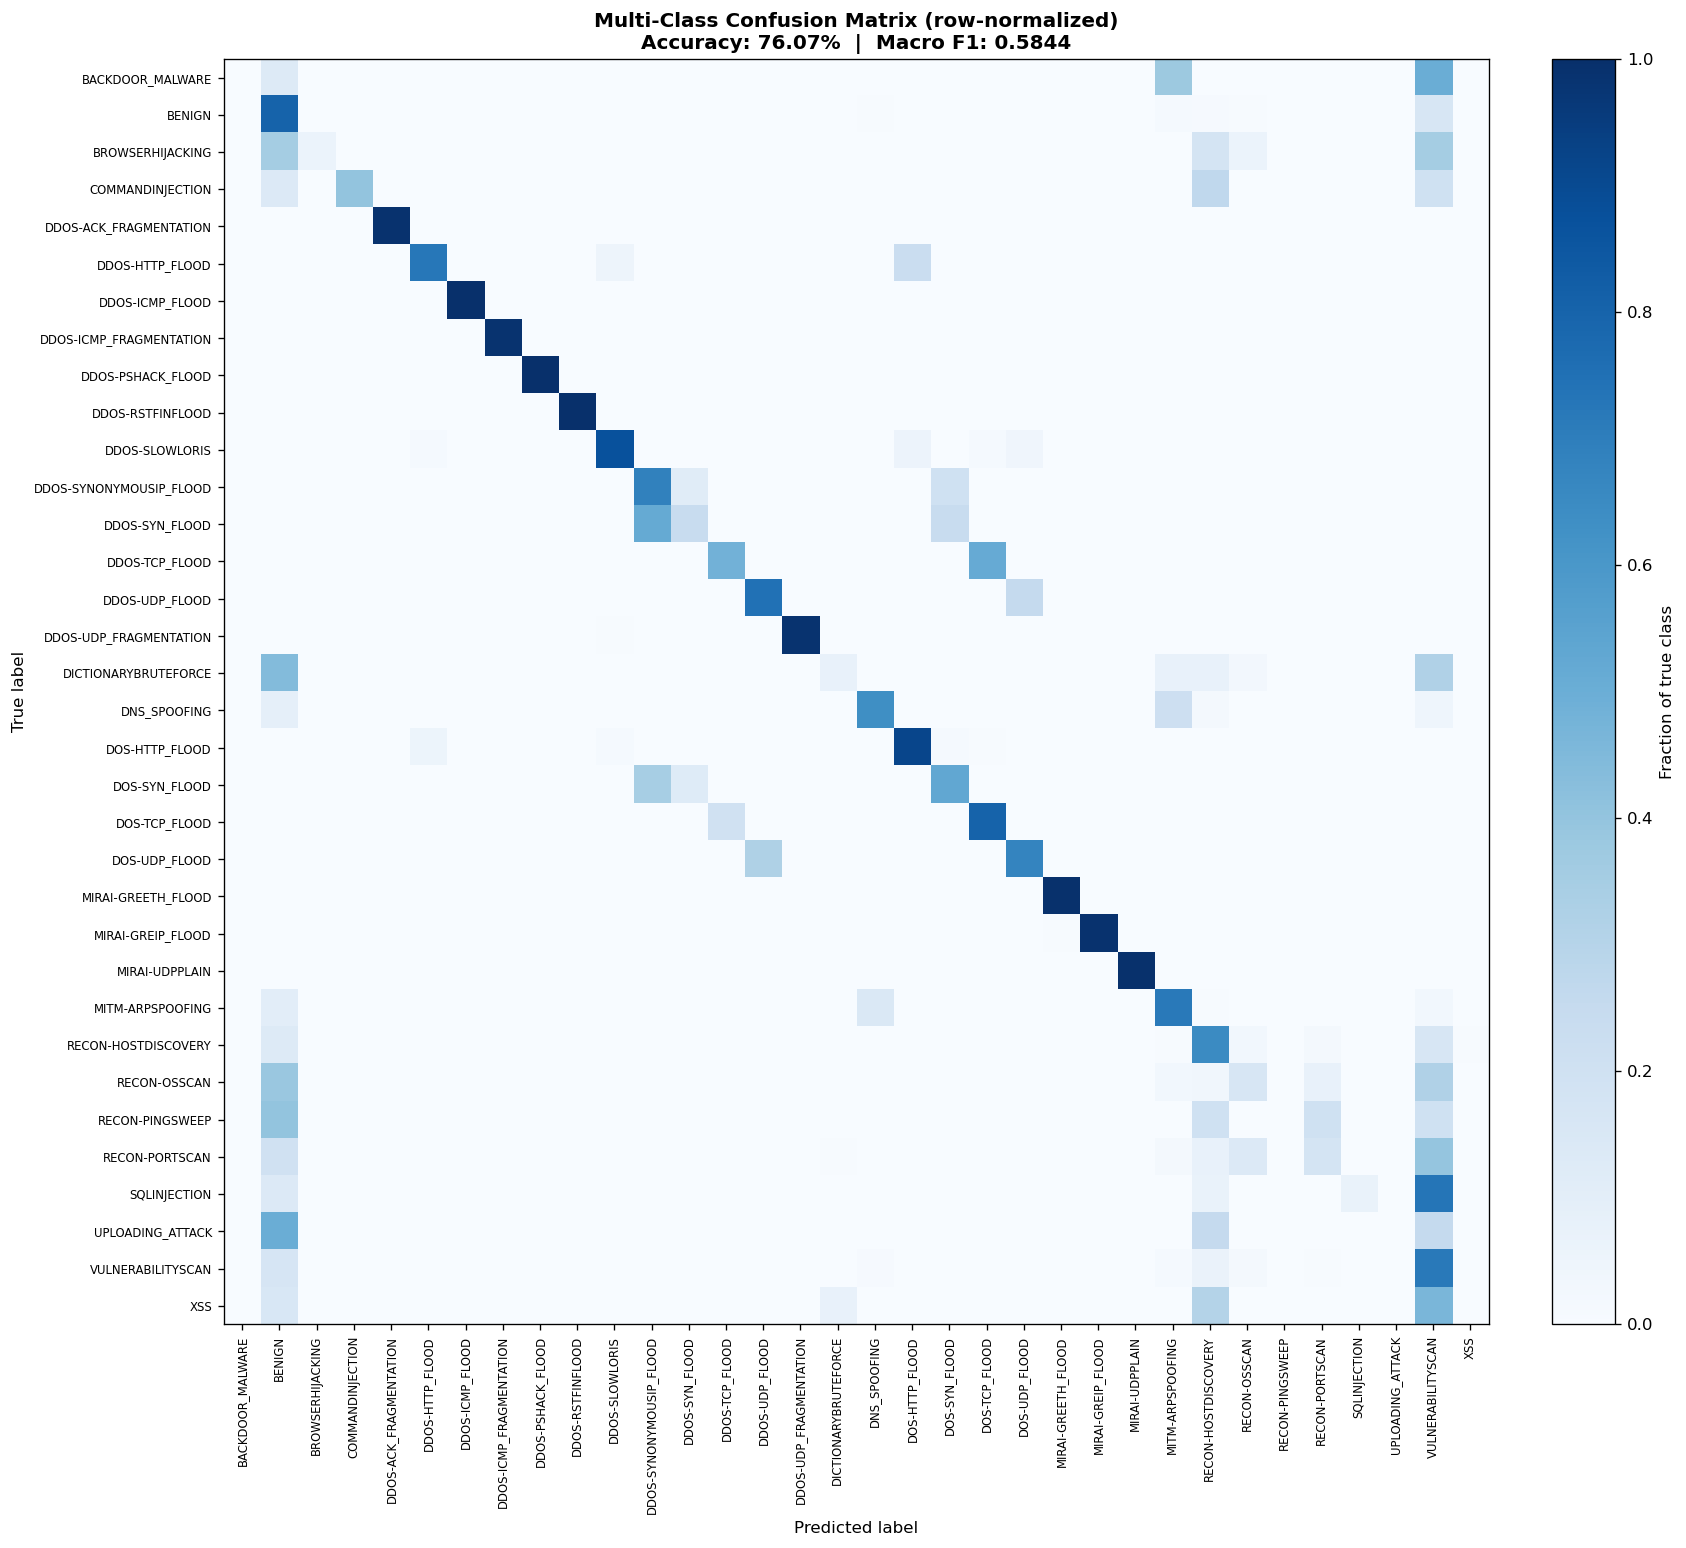

Diagonal (per-class recall) saved implicitly in the heatmap; rows are true classes.


In [10]:
cm_multi = confusion_matrix(y_test_m, y_pred_m, labels=range(len(encoder.classes_)), normalize='true')
fig, ax = plt.subplots(figsize=(15, 13))
im = ax.imshow(cm_multi, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(encoder.classes_)))
ax.set_yticks(range(len(encoder.classes_)))
ax.set_xticklabels(encoder.classes_, rotation=90, fontsize=7)
ax.set_yticklabels(encoder.classes_, fontsize=7)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title(f'Multi-Class Confusion Matrix (row-normalized)\nAccuracy: {acc_m*100:.2f}%  |  Macro F1: {f1_macro:.4f}', fontweight='bold')
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Fraction of true class')
plt.tight_layout()
plt.savefig('../results/multiclass_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()
print('Diagonal (per-class recall) saved implicitly in the heatmap; rows are true classes.')

### False Positive Rate (Multi-Class, Macro-Averaged)

In [11]:
from sklearn.metrics import confusion_matrix as _confusion_matrix
cm_m = _confusion_matrix(y_test_m, y_pred_m, labels=range(len(encoder.classes_)))
total_m = cm_m.sum()
fpr_per_class = []
for i in range(cm_m.shape[0]):
    fp_i = cm_m[:, i].sum() - cm_m[i, i]
    tn_i = total_m - cm_m[i, :].sum() - cm_m[:, i].sum() + cm_m[i, i]
    if (fp_i + tn_i) > 0:
        fpr_per_class.append(fp_i / (fp_i + tn_i))
fpr_m_macro = sum(fpr_per_class) / len(fpr_per_class)
print(f'Multi-class Macro-Averaged False Positive Rate (FPR): {fpr_m_macro:.4f} ({fpr_m_macro*100:.2f}%)')

Multi-class Macro-Averaged False Positive Rate (FPR): 0.0076 (0.76%)


## 7. Feature Importance

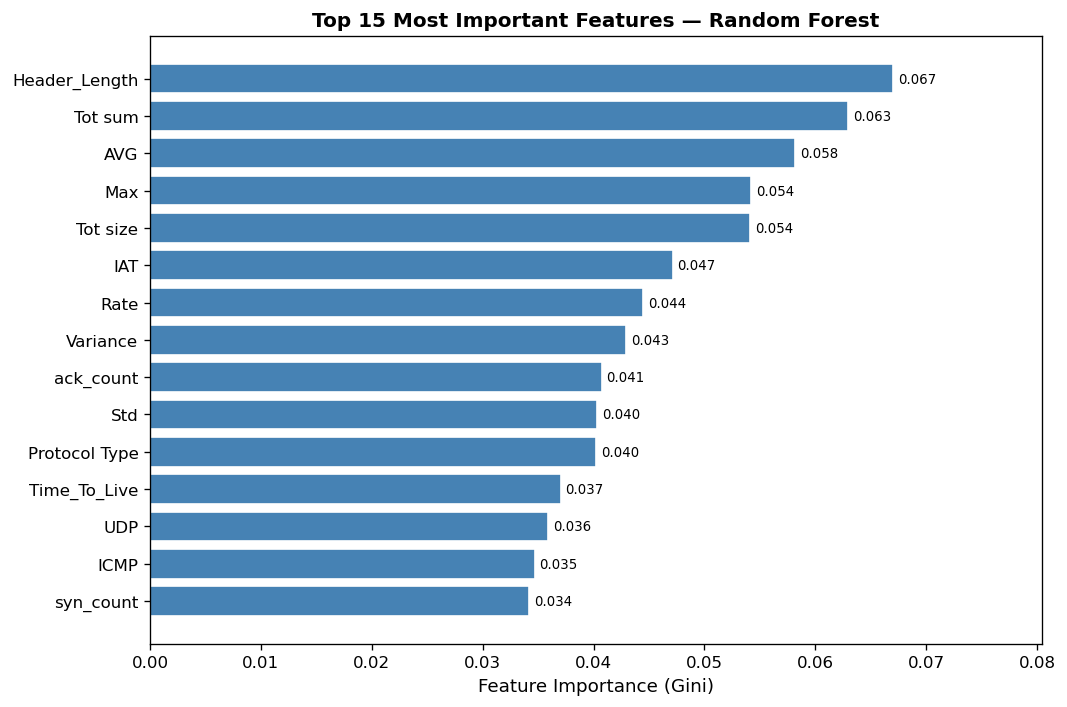

Top 5 features:
      Feature  Importance
Header_Length    0.067046
      Tot sum    0.062916
          AVG    0.058197
          Max    0.054178
     Tot size    0.054145


In [12]:
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_multi.feature_importances_
}).sort_values('Importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(importance_df['Feature'], importance_df['Importance'],
               color='steelblue', edgecolor='white')
ax.set_xlabel('Feature Importance (Gini)', fontsize=11)
ax.set_title('Top 15 Most Important Features — Random Forest', fontweight='bold', fontsize=12)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
ax.set_xlim(0, importance_df['Importance'].max() * 1.2)
plt.tight_layout()
plt.savefig('../results/feature_importance.png', bbox_inches='tight')
plt.show()

print('Top 5 features:')
print(importance_df.tail(5)[['Feature','Importance']].iloc[::-1].to_string(index=False))

## 8. Baseline Results Summary

In [13]:
print('         BASELINE MODEL RESULTS SUMMARY')
print(f'Dataset          : CICIoT2023 — Merged01.csv (1 full file, all rows)')
print(f'Total Samples    : {len(df_clean):,}')
print(f'Features         : {len(feature_cols)}')
print(f'Classes          : {len(encoder.classes_)}')
print(f'class_weight     : balanced')
print()
print(f'Binary  Accuracy          : {acc_b*100:.2f}%')
print(f'Binary  Balanced Accuracy : {bal_acc_b*100:.2f}%')
print(f'Binary  F1 (weighted)     : {f1_b:.4f}')
print(f'Binary  False Positive Rate: {fpr_b:.4f} ({fpr_b*100:.2f}%)')
print()
print(f'Multi   Accuracy          : {acc_m*100:.2f}%')
print(f'Multi   Balanced Accuracy : {bal_acc_m*100:.2f}%')
print(f'Multi   Macro F1          : {f1_macro:.4f}   ')
print(f'Multi   Weighted F1       : {f1_w:.4f}')
print(f'Multi   Macro FPR         : {fpr_m_macro:.4f} ({fpr_m_macro*100:.2f}%)')


         BASELINE MODEL RESULTS SUMMARY (FIXED)
Dataset          : CICIoT2023 — Merged01.csv (1 full file, all rows)
Total Samples    : 712,297
Features         : 39
Classes          : 34
class_weight     : balanced

Binary  Accuracy          : 99.20%
Binary  Balanced Accuracy : 91.02%
Binary  F1 (weighted)     : 0.9920
Binary  False Positive Rate: 0.1756 (17.56%)

Multi   Accuracy          : 76.07%
Multi   Balanced Accuracy : 59.00%
Multi   Macro F1          : 0.5844   
Multi   Weighted F1       : 0.7562
Multi   Macro FPR         : 0.0076 (0.76%)
